En esta actividad, vamos a poner en práctica todo lo que aprendimos sobre procesamiento de imágenes para crear un proyecto.

Objetivo: El objetivo de este proyecto es que utilicen procedimientos básicos de procesamiento de imágenes para leer una imagen, aplicarle mejoras, segmentar objetos y mostrar los resultados en una presentación visual.

Duración: Tenemos 1 hora para completar este desafío.

##Preparación:

Entorno: Vamos a usar Google Colab, que ya tiene todo lo que necesitamos instalado.

##Imágenes:

Les voy a proporcionar un conjunto de imágenes de ejemplo para que elijan la que más les guste. Hay de todo un poco: paisajes, objetos, retratos... ¡para que tengan variedad!

Si prefieren, ¡pueden usar sus propias fotos! Solo recuerden elegir una imagen con buena iluminación y calidad para que los resultados sean los mejores.

Google Colab: Este cuaderno ya está listo para que trabajen. Solo tienen que seguir las instrucciones y completar el código en los espacios indicados.

Pasos a seguir:

##1. ¡Empecemos importando las bibliotecas!
Lo primero que vamos a hacer es importar las herramientas que vamos a utilizar.

In [1]:
!pip install scikit-image watermark -q

# Install OpenCV package first
!pip install opencv-python -q

# First install the required system library
!apt-get update && apt-get install -y libgl1-mesa-glx

!pip install opencv-python


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Hit:1 http://deb.debian.org/debian bullseye InRelease
Hit:2 http://deb.debian.org/debian-security bullseye-security InRelease
Hit:3 http://deb.debian.org/debian bullseye-updates InRelease




libgl1-mesa-glx is already the newest version (20.3.5-1).
0 upgraded, 0 newly installed, 0 to remove and 75 not upgraded.

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## 2. Leyendo y viendo nuestra imagen
Subir la imagen: Si van a usar una foto propia, súbanla a Google Colab. Para hacerlo, hagan clic en el ícono de la carpeta en la barra lateral izquierda, luego en el ícono de "Subir" y seleccionen su archivo.

Leer la imagen: Con cv2.imread(), vamos a leer la imagen que eligieron. Recuerden que OpenCV lee las imágenes en formato BGR, así que la vamos a convertir a RGB para poder verla bien con Matplotlib.

Mostrar la imagen original: Usaremos matplotlib.pyplot para ver la imagen tal como es al principio.

In [3]:
!wget https://i.pinimg.com/736x/93/ee/76/93ee769ffbcf7a628d34b7857ab2d2e3.jpg

--2025-05-05 03:33:31--  https://i.pinimg.com/736x/93/ee/76/93ee769ffbcf7a628d34b7857ab2d2e3.jpg
Resolving i.pinimg.com (i.pinimg.com)... 151.101.64.84, 151.101.128.84, 151.101.192.84, ...
Connecting to i.pinimg.com (i.pinimg.com)|151.101.64.84|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 121633 (119K) [image/jpeg]
Saving to: ‘93ee769ffbcf7a628d34b7857ab2d2e3.jpg.5’

93ee769ffbcf7a628d3 100%[===================>] 118.78K  --.-KB/s    in 0.005s  

2025-05-05 03:33:31 (21.8 MB/s) - ‘93ee769ffbcf7a628d34b7857ab2d2e3.jpg.5’ saved [121633/121633]



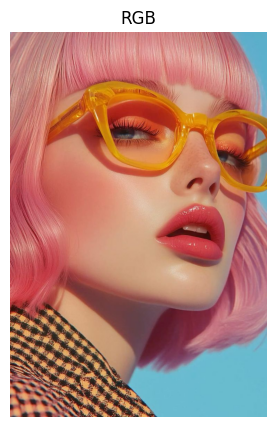

In [4]:
imagen_bgr = cv2.imread('gafas12.jpg')
if imagen_bgr is None:
    print("No se pudo cargar la imagen. Verificá el nombre y la ruta.")
else:
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 5))
    plt.imshow(imagen_rgb)
    plt.axis('off')
    plt.title('RGB')
    plt.show()

##3. ¡Mejorando nuestra imagen!
Ahora vamos a aplicar un par de técnicas para que nuestra imagen se vea aún mejor:

Ajuste de brillo y contraste: Vamos a crear una función para modificar estos aspectos de la imagen.

Ecualización de histograma: Con cv2.equalizeHist(), vamos a mejorar el contraste de la imagen.

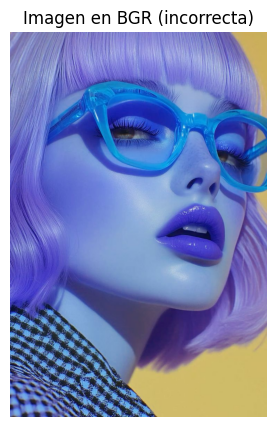

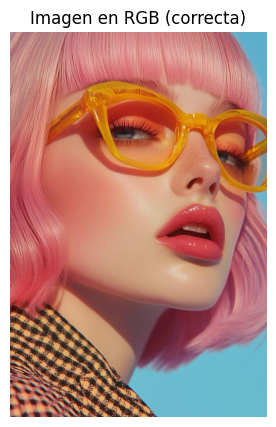

In [5]:
# Imagen original BGR
plt.figure(figsize=(10, 5))
plt.imshow(imagen_bgr)
plt.title('Imagen en BGR (incorrecta)')
plt.axis('off')
plt.show()

# Imagen convertida a RGB
sofa_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 5))
plt.imshow(imagen_rgb)
plt.title('Imagen en RGB (correcta)')
plt.axis('off')
plt.show()

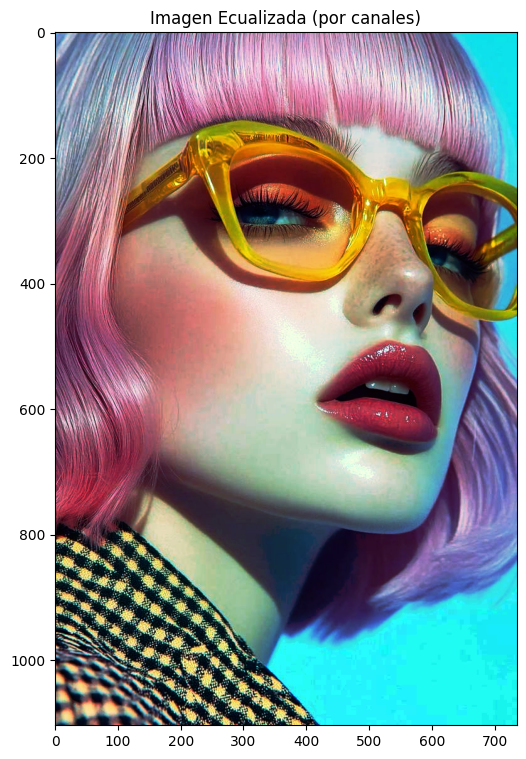

In [6]:
imagen_eqhst = imagen_bgr.copy()  # Hacer una copia de la imagen original
imagen_eqhst[:, :, 0] = cv2.equalizeHist(imagen_bgr[:, :, 0])  # Ecualizar el canal Rojo
imagen_eqhst[:, :, 1] = cv2.equalizeHist(imagen_bgr[:, :, 1])  # Ecualizar el canal Verde
imagen_eqhst[:, :, 2] = cv2.equalizeHist(imagen_bgr[:, :, 2])  # Ecualizar el canal Azul
plt.figure(figsize=(6, 9))  # Tamaño de la figura
plt.imshow(cv2.cvtColor(imagen_eqhst, cv2.COLOR_BGR2RGB))  # Mostrar la imagen ecualizada
plt.title('Imagen Ecualizada (por canales)')  # Título
plt.show()  # Mostrar

In [7]:
V = imagen_bgr.copy()  # Hacer una copia de la imagen original
imagen_hsv = cv2.cvtColor(V, cv2.COLOR_BGR2HSV)  # Convertir a HSV
imagen_hsv[:, :, 2] = cv2.equalizeHist(imagen_hsv[:, :, 2])  # Ecualizar el canal de brillo (V)
Knew_imagen = cv2.cvtColor(imagen_hsv, cv2.COLOR_HSV2BGR)  # Convertir de nuevo a BGR

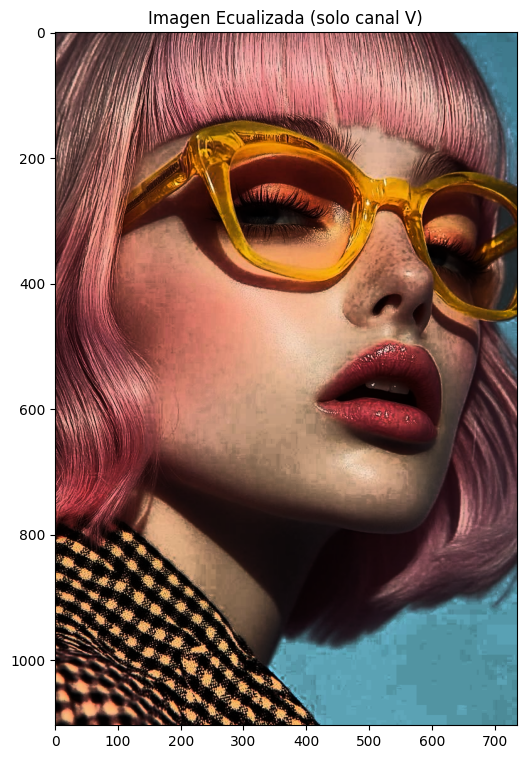

In [8]:
plt.figure(figsize=(6, 9))  # Tamaño de la figura
plt.imshow(cv2.cvtColor(Knew_imagen, cv2.COLOR_BGR2RGB))  # Mostrar la imagen ecualizada
plt.title('Imagen Ecualizada (solo canal V)')  # Título
plt.show()  # Mostrar figura

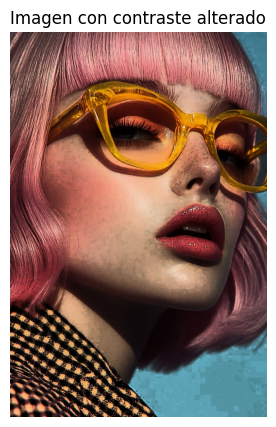

In [9]:
V = imagen_bgr.copy() 
imagen_hsv = cv2.cvtColor(V, cv2.COLOR_BGR2HSV)  
imagen_hsv[:, :, 2] = cv2.equalizeHist(imagen_hsv[:, :, 2])  
Knew_imagen = cv2.cvtColor(imagen_hsv, cv2.COLOR_HSV2BGR) 

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(Knew_imagen, cv2.COLOR_BGR2RGB))  # Mostrar la imagen con contraste alterado
plt.axis('off')
plt.title('Imagen con contraste alterado')
plt.show()

##4. ¡A segmentar por color!
Ahora viene una parte muy interesante: vamos a separar objetos de la imagen por su color.

Convertir a HSV: Vamos a pasar la imagen de RGB a HSV (Hue, Saturation, Value) porque es más fácil definir rangos de color en HSV.

Definir el rango de color: Vamos a establecer los límites inferior y superior del color que queremos segmentar. En el ejemplo, segmentamos el color rojo de las flores. ¡Presten mucha atención acá! Van a tener que ajustar estos valores para su propia imagen.

Crear una máscara: Con cv2.inRange(), vamos a crear una máscara que nos indique qué píxeles están dentro del rango de color y cuáles no.

Aplicar la máscara: Usaremos cv2.bitwise_and() para quedarnos solo con la parte de la imagen que corresponde al color que elegimos.

In [10]:
#convierto a hsv para poder ecualizar

imagen_hsv_1 = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)

# Guardar una copia del canal V original antes de ecualizar
v_original = imagen_hsv_1[:, :, 2].copy()

#ecualizo canal V sobre la imagen
v_ecualizado = imagen_hsv_1[:, :, 2]= cv2.equalizeHist(imagen_hsv_1[:, :, 2])  # Ecualiza el canal

In [11]:
def aplicar_mascara_amarillo(imagen_bgr, h_min=16, h_max=50, s_min=100, s_max=255, v_min=100, v_max=255):
    imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)

    amarillo_bajo = np.array([h_min, s_min, v_min])
    amarillo_alto = np.array([h_max, s_max, v_max])

    mascara_amarillo = cv2.inRange(imagen_hsv, amarillo_bajo, amarillo_alto)
    resultado = cv2.bitwise_and(imagen_bgr, imagen_bgr, mask=mascara_amarillo)

    return resultado, mascara_amarillo

In [12]:
'''
esta funcion primero segmenta y luego muestra la segmentacion con matplotlib
'''


def ejercicio_segmentar_y_mostrar():
    # Segmentar el color 
    resultado, _ = aplicar_mascara_amarillo(
        imagen_bgr,
        h_min=16, h_max=50,
        s_min=100, s_max=255,
        v_min=100, v_max=255
    )

    # Convertir a RGB para mostrar
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

    # Mostrar original y segmentada
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(imagen_rgb)
    plt.title("Imagen original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(resultado_rgb)
    plt.title("Imagen segmentada (fondo negro)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


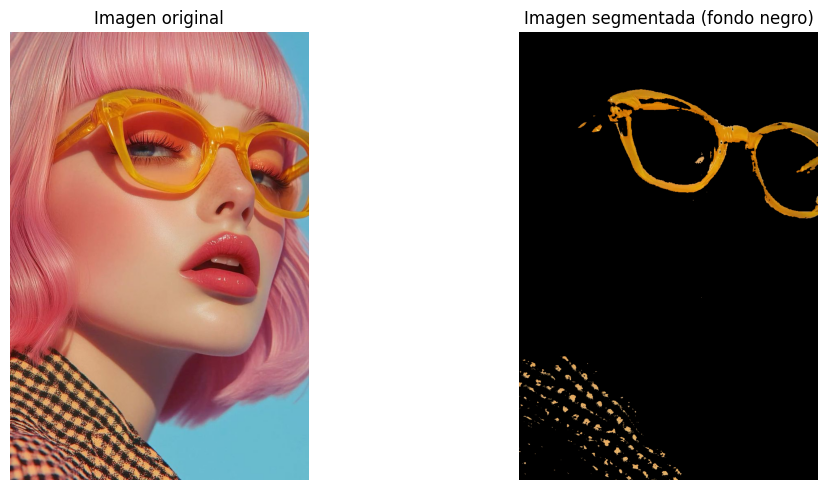

In [13]:
ejercicio_segmentar_y_mostrar()

In [14]:
def aplicar_mascara_amarillo(imagen_bgr, h_min=16, h_max=50, s_min=100, s_max=255, v_min=100, v_max=255, tamaño_kernel=(5, 5)):
    imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)

    amarillo_bajo = np.array([h_min, s_min, v_min])
    amarillo_alto = np.array([h_max, s_max, v_max])

    # Crear la mascara para el color amarillo
    mascara_amarillo = cv2.inRange(imagen_hsv, amarillo_bajo, amarillo_alto)

    # Aplicar apertura para eliminar pequeños puntos aislados
    kernel = np.ones(tamaño_kernel, np.uint8)
    mascara_amarillo = cv2.morphologyEx(mascara_amarillo, cv2.MORPH_OPEN, kernel)

    # Aplicar la mascara a la imagen original
    resultado = cv2.bitwise_and(imagen_bgr, imagen_bgr, mask=mascara_amarillo)

    return resultado, mascara_amarillo



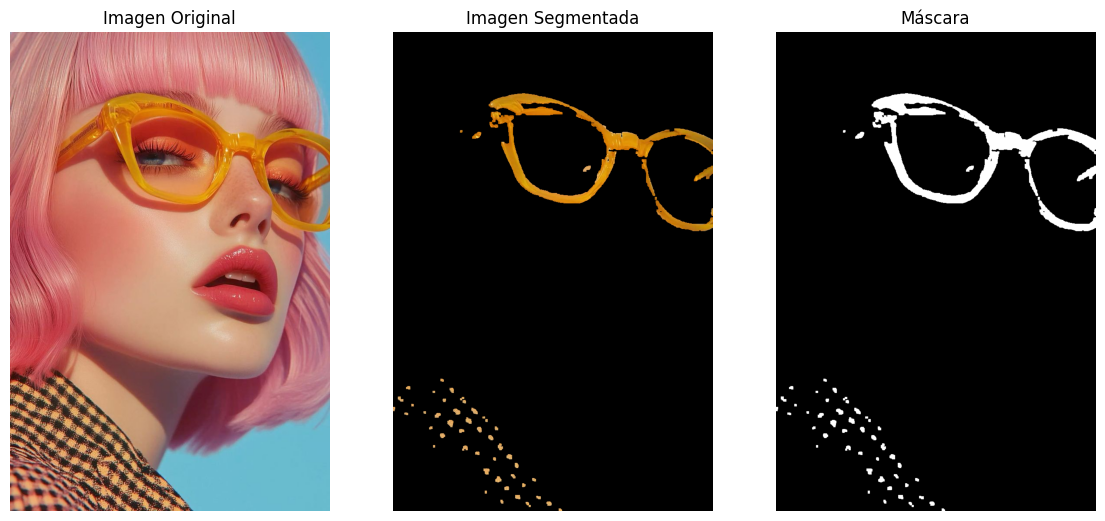

In [15]:
# Cargar la imagen original - corregido el nombre del archivo
imagen_bgr = cv2.imread('gafas12.jpg') 

# Verificar si la imagen se cargó correctamente
if imagen_bgr is None:
    print("Error: No se pudo cargar la imagen. Verifique el nombre del archivo.")
else:
    # Obtener los resultados
    resultado, mascara_amarillo = aplicar_mascara_amarillo(imagen_bgr)

    # Convertir de BGR a RGB para mostrar con matplotlib
    resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)
    
    # Para la máscara, no necesitamos convertir de BGR a RGB ya que es una imagen binaria
    # La máscara es una imagen en escala de grises (un solo canal)
    
    # Mostrar las imágenes segmentadas y la máscara
    plt.figure(figsize=(14, 8))

    # Imagen segmentada
    plt.subplot(1, 3, 1)
    plt.imshow(imagen_rgb)
    plt.axis('off')
    plt.title("Imagen Original")

    # Imagen segmentada
    plt.subplot(1, 3, 2)
    plt.imshow(resultado_rgb)
    plt.axis('off')
    plt.title("Imagen Segmentada")

    # Máscara amarilla
    plt.subplot(1, 3, 3)
    plt.imshow(mascara_amarillo, cmap='gray')  # Usar cmap='gray' para máscara binaria
    plt.axis('off')
    plt.title("Máscara")

    plt.show()

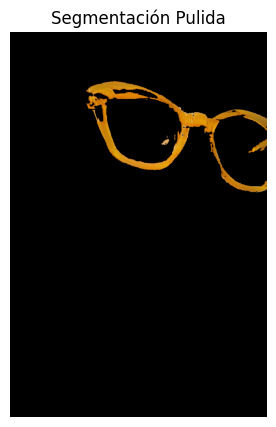

In [16]:
def limpiar_imagen_con_gafas(mascara, umbral_min_area=500):
    # Encuentra los contornos de la máscara
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Crear una copia de la máscara
    limpia = mascara.copy()

    # Filtrar los contornos pequeños y mantener solo los más grandes (como las gafas)
    for contorno in contornos:
        area = cv2.contourArea(contorno)
        if area < umbral_min_area:  # Si el área es pequeña, la ignoramos
            cv2.drawContours(limpia, [contorno], -1, (0), thickness=cv2.FILLED)  # Rellenamos los contornos pequeños con negro
    
    return limpia

# Cargar la imagen original
imagen_bgr = cv2.imread('gafas12.jpg')

# Verificar si la imagen se carga correctamente
if imagen_bgr is None:
    print("Error: No se pudo cargar la imagen. Verifique el nombre del archivo.")
else:
    # Convertir la imagen a HSV
    imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)

    # Definir los límites del color amarillo (ajustar estos valores si es necesario)
    h_min, h_max, s_min, s_max, v_min, v_max = 16, 50, 100, 255, 100, 255
    amarillo_bajo = np.array([h_min, s_min, v_min])
    amarillo_alto = np.array([h_max, s_max, v_max])

    # Crear la máscara para el color amarillo
    mascara_amarillo = cv2.inRange(imagen_hsv, amarillo_bajo, amarillo_alto)

    # Limpiar la imagen, eliminando puntos pequeños no deseados
    mascara_limpia = limpiar_imagen_con_gafas(mascara_amarillo)



    # Aplicar la máscara limpia a la imagen original
    resultado = cv2.bitwise_and(imagen_bgr, imagen_bgr, mask=mascara_limpia)

    # Convertir la imagen resultante a RGB para visualizarla correctamente
    resultado_rgb_limpia = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen original con la máscara aplicada
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 2)
    plt.imshow(resultado_rgb_limpia)
    plt.title("Segmentación Pulida")
    plt.axis('off')
    plt.show()


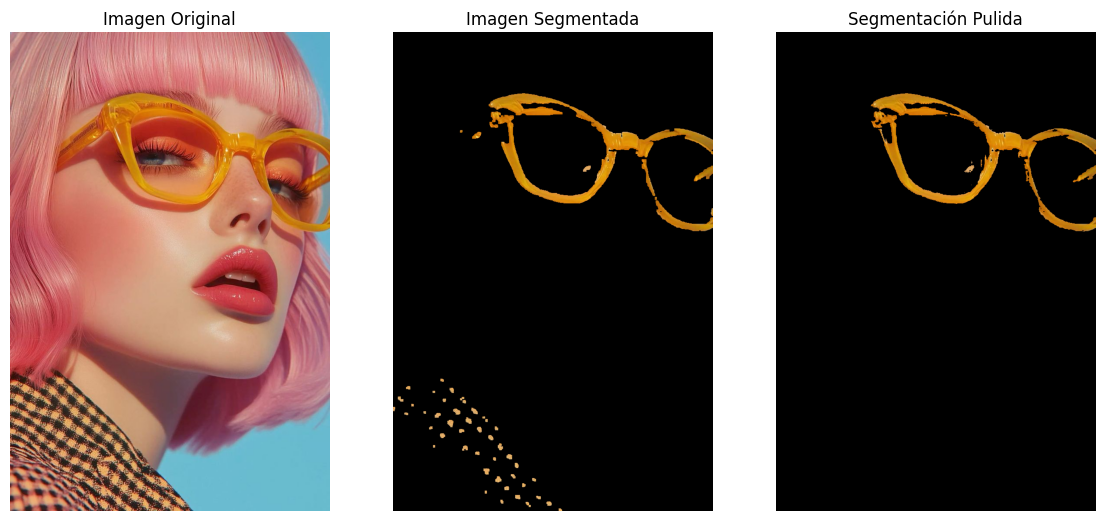

In [17]:
# Cargar la imagen original - corregido el nombre del archivo
imagen_bgr = cv2.imread('gafas12.jpg') 

# Verificar si la imagen se cargó correctamente
if imagen_bgr is None:
    print("Error: No se pudo cargar la imagen. Verifique el nombre del archivo.")
else:
    # Obtener los resultados
    resultado, mascara_amarillo = aplicar_mascara_amarillo(imagen_bgr)

    # Convertir de BGR a RGB para mostrar con matplotlib
    resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)
    
    # Para la máscara, no necesitamos convertir de BGR a RGB ya que es una imagen binaria
    # La máscara es una imagen en escala de grises (un solo canal)
    
    # Mostrar las imágenes segmentadas y la máscara
    plt.figure(figsize=(14, 8))

    # Imagen segmentada
    plt.subplot(1, 3, 1)
    plt.imshow(imagen_rgb)
    plt.axis('off')
    plt.title("Imagen Original")

    # Imagen segmentada
    plt.subplot(1, 3, 2)
    plt.imshow(resultado_rgb)
    plt.axis('off')
    plt.title("Imagen Segmentada")

    # Máscara amarilla
    plt.subplot(1, 3, 3)
    plt.imshow(resultado_rgb_limpia, cmap='gray')  # Usar cmap='gray' para máscara binaria
    plt.axis('off')
    plt.title("Segmentación Pulida")

    plt.show()

##5. ¡Dibujando y escribiendo sobre la imagen!
Para terminar, vamos a agregarle un poco de información a nuestra imagen segmentada.

Dibujar rectángulos: Con cv2.findContours() vamos a encontrar los contornos de los objetos que segmentamos, y con cv2.boundingRect() vamos a obtener las coordenadas para dibujar un rectángulo alrededor de ellos. Usaremos cv2.rectangle() para dibujar el rectángulo.

Agregar texto: Con cv2.putText(), vamos a agregar un texto que describa los objetos que segmentamos.

##6. Presentaciones preliminares

Cada uno/una de ustedes va a tener 5 minutos para mostrarnos su trabajo, que debe incluir:

La imagen original.

La imagen mejorada (ya sea con ajuste de brillo/contraste o ecualización de histograma).

La imagen segmentada.

Una explicación de todo el proceso, incluyendo:

La imagen que eligieron y por qué.

Los valores que usaron para ajustar el brillo y el contraste (si lo hicieron).

El rango de color HSV que eligieron para segmentar y por qué.

Cualquier dificultad que hayan tenido y cómo la resolvieron.

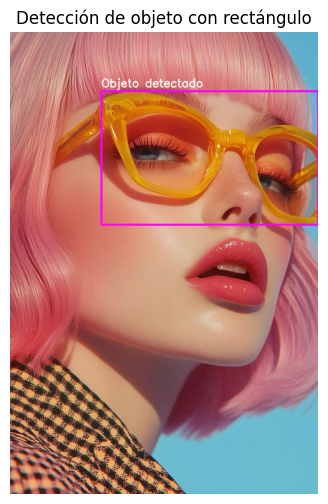

In [18]:
def aplicar_mascara_amarillo(imagen_bgr, h_min=16, h_max=50, s_min=100, s_max=255, v_min=100, v_max=255):
    imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)

    amarillo_bajo = np.array([h_min, s_min, v_min])
    amarillo_alto = np.array([h_max, s_max, v_max])

    # Crear la máscara para el color amarillo
    mascara_amarillo = cv2.inRange(imagen_hsv, amarillo_bajo, amarillo_alto)

    # Aplicar la máscara a la imagen original
    resultado = cv2.bitwise_and(imagen_bgr, imagen_bgr, mask=mascara_amarillo)

    return resultado, mascara_amarillo

def dibujar_rectangulo(imagen_bgr, limpia):
    contornos, _ = cv2.findContours(limpia, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    imagen_con_info = imagen_bgr.copy()

    if contornos:
        contorno_principal = max(contornos, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(contorno_principal)
        cv2.rectangle(imagen_con_info, (x, y), (x + w, y + h), (255, 0, 255), 3)
        cv2.putText(imagen_con_info, 'Objeto detectado', (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
    return imagen_con_info

def ejercicio_rectangulo_en_original(imagen_bgr):
    # Segmentar y obtener máscara
    resultado, _ = aplicar_mascara_amarillo(
        imagen_bgr,
        h_min=16, h_max=50,
        s_min=100, s_max=255,
        v_min=100, v_max=255
    )

    # Convertir la imagen segmentada a escala de grises y luego a binaria
    resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)
    resultado_gris = cv2.cvtColor(resultado_rgb, cv2.COLOR_RGB2GRAY)
    _, mascara_binaria = cv2.threshold(resultado_gris, 10, 255, cv2.THRESH_BINARY)

    # Dibujar rectángulo sobre la imagen original
    imagen_con_info = dibujar_rectangulo(imagen_bgr, mascara_binaria)

    # Convertir la imagen con el rectángulo a formato RGB para mostrar con matplotlib
    imagen_con_info_rgb = cv2.cvtColor(imagen_con_info, cv2.COLOR_BGR2RGB)

    # Mostrar imagen original con rectángulo
    plt.figure(figsize=(6, 6))
    plt.imshow(imagen_con_info_rgb)
    plt.title("Detección de objeto con rectángulo")
    plt.axis("off")
    plt.show()

# Cargar la imagen
imagen_bgr = cv2.imread('gafas12.jpg')  # Asegúrate de que el archivo esté en la ruta correcta

# Verificar si la imagen se carga correctamente
if imagen_bgr is None:
    print("Error: No se pudo cargar la imagen. Verifique el nombre del archivo.")
else:
    ejercicio_rectangulo_en_original(imagen_bgr)


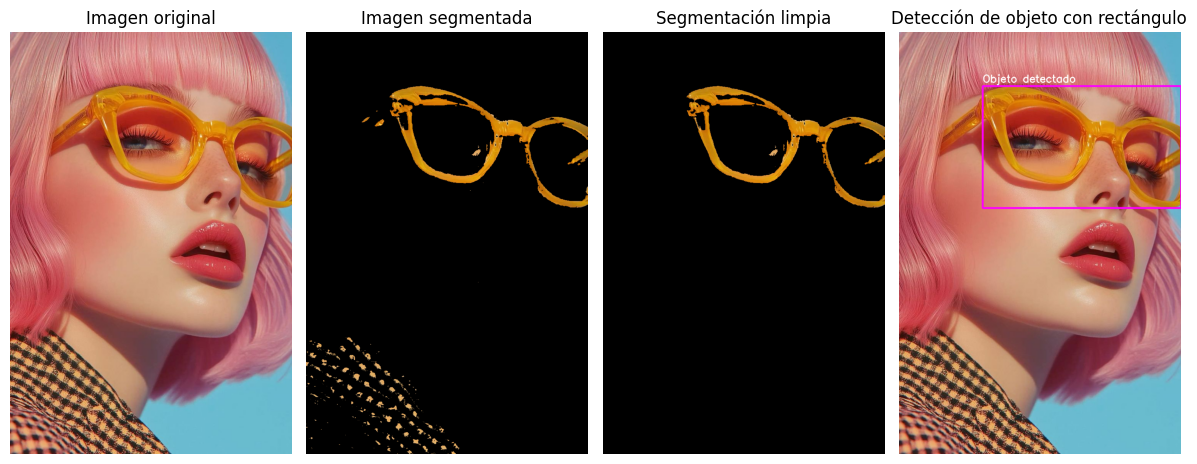

In [19]:
# Definimos todas las funciones necesarias primero
def aplicar_mascara_amarillo(imagen_bgr, h_min=16, h_max=50, s_min=100, s_max=255, v_min=100, v_max=255):
    imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)
    amarillo_bajo = np.array([h_min, s_min, v_min])
    amarillo_alto = np.array([h_max, s_max, v_max])
    mascara_amarillo = cv2.inRange(imagen_hsv, amarillo_bajo, amarillo_alto)
    resultado = cv2.bitwise_and(imagen_bgr, imagen_bgr, mask=mascara_amarillo)
    return resultado, mascara_amarillo

def dibujar_rectangulo(imagen_bgr, limpia):
    contornos, _ = cv2.findContours(limpia, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    imagen_con_info = imagen_bgr.copy()
    if contornos:
        contorno_principal = max(contornos, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(contorno_principal)
        cv2.rectangle(imagen_con_info, (x, y), (x + w, y + h), (255, 0, 255), 3)
        cv2.putText(imagen_con_info, 'Objeto detectado', (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
    return imagen_con_info

# Cargar la imagen
imagen_bgr = cv2.imread('gafas12.jpg')

if imagen_bgr is None:
    print("Error: No se pudo cargar la imagen")
else:
    # Obtener la imagen segmentada y la máscara
    resultado, mascara_amarillo = aplicar_mascara_amarillo(imagen_bgr)
    resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)
    
    # Obtener la máscara limpia
    resultado_gris = cv2.cvtColor(resultado, cv2.COLOR_BGR2GRAY)
    _, mascara_binaria = cv2.threshold(resultado_gris, 10, 255, cv2.THRESH_BINARY)
    
    # Obtener la imagen con el rectángulo
    imagen_con_info = dibujar_rectangulo(imagen_bgr, mascara_binaria)
    imagen_con_info_rgb = cv2.cvtColor(imagen_con_info, cv2.COLOR_BGR2RGB)
    
    # Mostrar las imágenes
    plt.figure(figsize=(12, 6))

    # Mostrar imagen original
    plt.subplot(1, 4, 1)
    plt.imshow(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Imagen original")
    plt.axis("off")


    # Mostrar imagen con color en máscara
    plt.subplot(1, 4, 2)
    plt.imshow(resultado_rgb)
    plt.title("Imagen segmentada")
    plt.axis("off")
    
    # Mostrar máscara limpia
    plt.subplot(1, 4, 3)
    plt.imshow(resultado_rgb_limpia, cmap='gray')
    plt.title("Segmentación limpia")
    plt.axis("off")

    # Mostrar imagen original con rectángulo
    plt.subplot(1, 4, 4)
    plt.imshow(imagen_con_info_rgb)
    plt.title("Detección de objeto con rectángulo")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

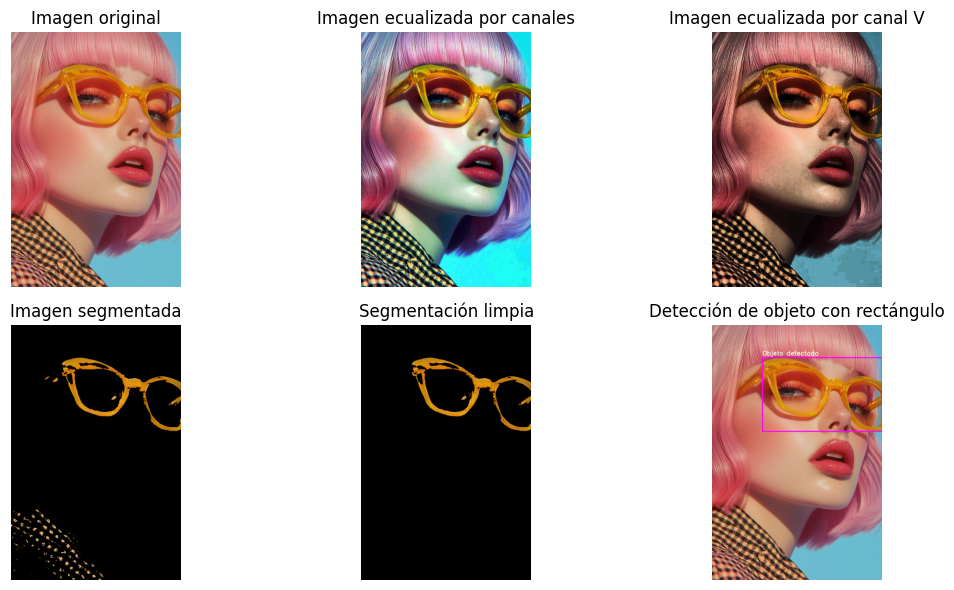

In [20]:
# Definimos todas las funciones necesarias primero
def aplicar_mascara_amarillo(imagen_bgr, h_min=16, h_max=50, s_min=100, s_max=255, v_min=100, v_max=255):
    imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)
    amarillo_bajo = np.array([h_min, s_min, v_min])
    amarillo_alto = np.array([h_max, s_max, v_max])
    mascara_amarillo = cv2.inRange(imagen_hsv, amarillo_bajo, amarillo_alto)
    resultado = cv2.bitwise_and(imagen_bgr, imagen_bgr, mask=mascara_amarillo)
    return resultado, mascara_amarillo

def dibujar_rectangulo(imagen_bgr, limpia):
    contornos, _ = cv2.findContours(limpia, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    imagen_con_info = imagen_bgr.copy()
    if contornos:
        contorno_principal = max(contornos, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(contorno_principal)
        cv2.rectangle(imagen_con_info, (x, y), (x + w, y + h), (255, 0, 255), 3)
        cv2.putText(imagen_con_info, 'Objeto detectado', (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
    return imagen_con_info

# Cargar la imagen
imagen_bgr = cv2.imread('gafas12.jpg')

if imagen_bgr is None:
    print("Error: No se pudo cargar la imagen")
else:
    # Obtener la imagen segmentada y la máscara
    resultado, mascara_amarillo = aplicar_mascara_amarillo(imagen_bgr)
    resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)
    
    # Obtener la máscara limpia
    resultado_gris = cv2.cvtColor(resultado, cv2.COLOR_BGR2GRAY)
    _, mascara_binaria = cv2.threshold(resultado_gris, 10, 255, cv2.THRESH_BINARY)
    
    # Obtener la imagen con el rectángulo
    imagen_con_info = dibujar_rectangulo(imagen_bgr, mascara_binaria)
    imagen_con_info_rgb = cv2.cvtColor(imagen_con_info, cv2.COLOR_BGR2RGB)
    
    # Mostrar las imágenes
    plt.figure(figsize=(12, 6))

    # Mostrar imagen original
    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Imagen original")
    plt.axis("off")

    # Mostrar imagen con color en máscara
    plt.subplot(2, 3, 2)
    plt.imshow(cv2.cvtColor(imagen_eqhst, cv2.COLOR_BGR2RGB))
    plt.title("Imagen ecualizada por canales")
    plt.axis("off")
    
    # Mostrar máscara limpia
    plt.subplot(2, 3, 3)
    plt.imshow(cv2.cvtColor(Knew_imagen, cv2.COLOR_BGR2RGB))
    plt.title("Imagen ecualizada por canal V")
    plt.axis("off")


    # Mostrar imagen con color en máscara
    plt.subplot(2, 3, 4)
    plt.imshow(resultado_rgb)
    plt.title("Imagen segmentada")
    plt.axis("off")
    
    # Mostrar máscara limpia
    plt.subplot(2, 3, 5)
    plt.imshow(resultado_rgb_limpia, cmap='gray')
    plt.title("Segmentación limpia")
    plt.axis("off")

    # Mostrar imagen original con rectángulo
    plt.subplot(2, 3, 6)
    plt.imshow(imagen_con_info_rgb)
    plt.title("Detección de objeto con rectángulo")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=9be9d3e5-4f25-48e6-912d-b59b8644d952' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>